# PM2.5 Auto-Retrain Pipeline

This notebook demonstrates the end-to-end retraining workflow:
1. Load new labeled data
2. Check current model performance
3. **Generate mock data to simulate distribution shift → force retrain**
4. Send to `/retrain` API — triggers retraining automatically if MAE > threshold
5. Poll Airflow until the training run completes
6. Compare old vs new model performance

**Prerequisites:** `docker compose up -d` must be running.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

API_URL      = 'http://localhost:8001'
AIRFLOW_URL  = 'http://localhost:8080'
AIRFLOW_AUTH = ('admin', 'admin')

print('API     :', requests.get(f'{API_URL}/health').json())
print('Airflow :', requests.get(f'{AIRFLOW_URL}/health', auth=AIRFLOW_AUTH).json())

API     : {'status': 'ok'}
Airflow : {'dag_processor': {'latest_dag_processor_heartbeat': None, 'status': None}, 'metadatabase': {'status': 'healthy'}, 'scheduler': {'latest_scheduler_heartbeat': '2026-03-19T16:33:57.459593+00:00', 'status': 'healthy'}, 'triggerer': {'latest_triggerer_heartbeat': None, 'status': None}}


## 1. Load New Labeled Data

Replace the file path below with your new data file. It must contain `date` and `pm25` columns.

In [2]:
from data_loader import load_config, load_station_data
from preprocessing import preprocess_pipeline

config = load_config('../configs/config.yaml')

# ── Change this path to your new data file ───────────────────────────────────
NEW_DATA_FILE  = '../data/raw/PM2.5(2025).xlsx'
NEW_DATA_SHEET = 'DATA'
# ─────────────────────────────────────────────────────────────────────────────

raw_df   = load_station_data(NEW_DATA_FILE, NEW_DATA_SHEET, config['station']['id'])
clean_df = preprocess_pipeline(raw_df)

print(f'Loaded {len(clean_df)} days  ({clean_df["date"].min().date()} → {clean_df["date"].max().date()})')
clean_df.tail()

Preprocessing pipeline:
  Missing values: 0 → 0 (method=ffill)
  Final shape: (181, 2)
Loaded 181 days  (2025-01-01 → 2025-06-30)


,date,pm25
176,2025-06-26,14.0
177,2025-06-27,13.2
178,2025-06-28,15.5
179,2025-06-29,13.3
180,2025-06-30,16.2


## 2. Check Current Model Performance

In [3]:
import json
import joblib
from feature_engineering import build_features
from evaluate import evaluate_model

with open('../models/feature_columns.json') as f:
    feature_cols = json.load(f)

model   = joblib.load('../models/random_forest.joblib')
feat_df = build_features(clean_df, config['features']['lag_days'], config['features']['rolling_windows'])
X, y    = feat_df[feature_cols].values, feat_df['pm25'].values
y_pred  = model.predict(X)
metrics = evaluate_model(y, y_pred)

print('Current model performance on new data:')
print(f"  MAE  : {metrics['MAE']:.4f} µg/m³")
print(f"  RMSE : {metrics['RMSE']:.4f} µg/m³")
print(f"  R²   : {metrics['R2']:.4f}")

Current model performance on new data:
  MAE  : 4.5820 µg/m³
  RMSE : 6.6774 µg/m³
  R²   : 0.7774


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


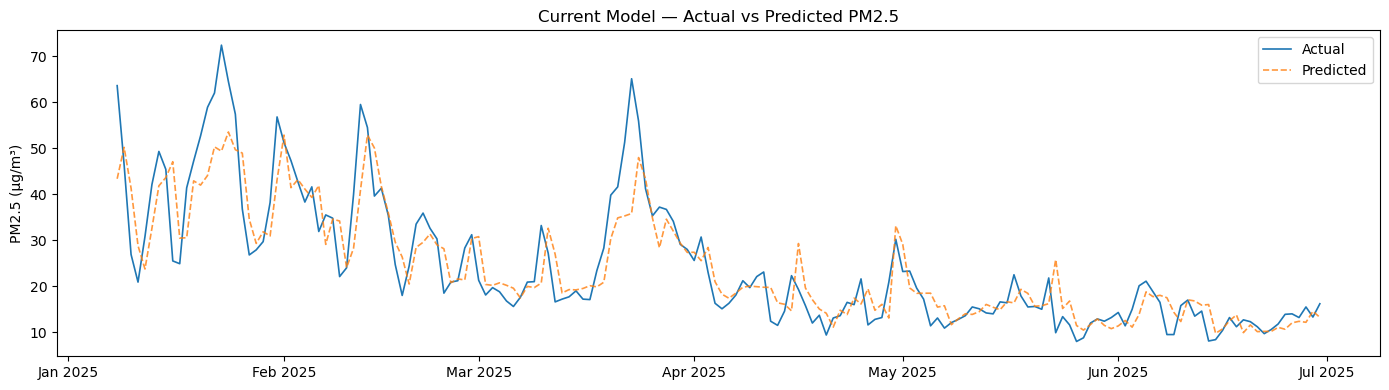

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
dates = feat_df['date'].values
ax.plot(dates, y,      label='Actual',    linewidth=1.2)
ax.plot(dates, y_pred, label='Predicted', linewidth=1.2, linestyle='--', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set(title='Current Model — Actual vs Predicted PM2.5', ylabel='PM2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Generate Mock Data to Force Retrain

Simulates a scenario where the environment has changed and the model is now performing poorly.

Three modes — pick one by setting `MOCK_MODE`:

| Mode | What it simulates |
|------|-------------------|
| `spike` | Sudden pollution episode — values jump 2–3x higher than normal |
| `shift` | Gradual seasonal drift — mean shifts up by ~20 µg/m³ over time |
| `noise` | Sensor degradation — large random noise added to readings |

All modes use real dates so features (day_of_week, month, etc.) remain valid.

In [13]:
np.random.seed(99)

MOCK_MODE = 'spike'   # 'spike' | 'shift' | 'noise'
N_DAYS    = 60        # how many days of mock data to generate

# Use real dates from the tail of clean_df
base_df  = clean_df.tail(N_DAYS).copy().reset_index(drop=True)
real_pm25 = base_df['pm25'].values.copy()

if MOCK_MODE == 'spike':
    # Simulate a pollution episode: values spike to 2–3x normal
    spike_factor = np.random.uniform(2.0, 3.0, size=N_DAYS)
    mock_pm25    = np.clip(real_pm25 * spike_factor, 0, 500)
    description  = f'Spike mode — values multiplied by {spike_factor.mean():.1f}x on average'

elif MOCK_MODE == 'shift':
    # Simulate gradual seasonal drift — mean creeps up by ~20 µg/m³
    drift      = np.linspace(0, 20, N_DAYS)
    mock_pm25  = np.clip(real_pm25 + drift + np.random.normal(0, 3, N_DAYS), 0, 500)
    description = 'Shift mode — gradual upward drift of +20 µg/m³ over the period'

elif MOCK_MODE == 'noise':
    # Simulate sensor degradation — large random noise
    noise      = np.random.normal(0, 20, N_DAYS)
    mock_pm25  = np.clip(real_pm25 + noise, 0, 500)
    description = 'Noise mode — sensor noise with std=20 µg/m³'

else:
    raise ValueError(f'Unknown MOCK_MODE: {MOCK_MODE}')

mock_df = pd.DataFrame({'date': base_df['date'], 'pm25': mock_pm25})

print(f'Mock mode  : {MOCK_MODE}')
print(f'Description: {description}')
print(f'Days       : {N_DAYS}')
print(f'Real  PM2.5 — mean: {real_pm25.mean():.1f}  std: {real_pm25.std():.1f}  max: {real_pm25.max():.1f}')
print(f'Mock  PM2.5 — mean: {mock_pm25.mean():.1f}  std: {mock_pm25.std():.1f}  max: {mock_pm25.max():.1f}')

Mock mode  : spike
Description: Spike mode — values multiplied by 2.5x on average
Days       : 60
Real  PM2.5 — mean: 14.0  std: 3.5  max: 23.3
Mock  PM2.5 — mean: 34.9  std: 9.4  max: 62.3


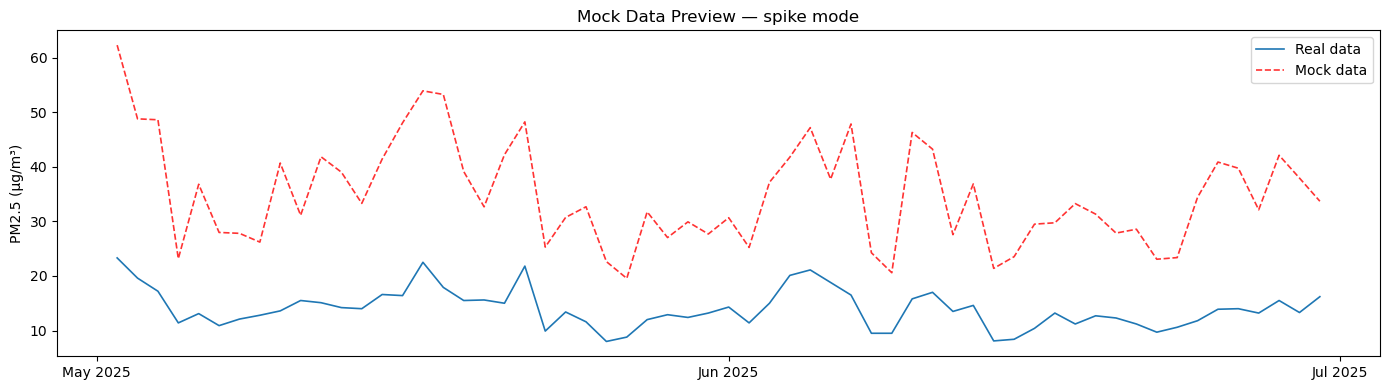

In [14]:
# Preview mock data vs real
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(base_df['date'], real_pm25, label='Real data',  linewidth=1.2)
ax.plot(mock_df['date'], mock_pm25, label='Mock data',  linewidth=1.2, linestyle='--', color='red', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set(title=f'Mock Data Preview — {MOCK_MODE} mode', ylabel='PM2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Show expected MAE on mock data before sending to API
mock_feat_df = build_features(
    mock_df,
    config['features']['lag_days'],
    config['features']['rolling_windows']
)

if not mock_feat_df.empty:
    X_mock  = mock_feat_df[feature_cols].values
    y_mock  = mock_feat_df['pm25'].values
    pred_mock = model.predict(X_mock)
    mock_metrics = evaluate_model(y_mock, pred_mock)

    print('Expected model performance on mock data:')
    print(f"  MAE  : {mock_metrics['MAE']:.4f} µg/m³  (real data MAE was {metrics['MAE']:.4f})")
    print(f"  RMSE : {mock_metrics['RMSE']:.4f} µg/m³")
    print(f"  R²   : {mock_metrics['R2']:.4f}")
    print(f"\nThis will trigger retrain if threshold ≤ {mock_metrics['MAE']:.2f}")
else:
    print('Not enough rows after feature engineering — increase N_DAYS to at least 20.')

Expected model performance on mock data:
  MAE  : 7.1721 µg/m³  (real data MAE was 4.5820)
  RMSE : 9.0987 µg/m³
  R²   : -0.1177

This will trigger retrain if threshold ≤ 7.17


## 4. Send Mock Data to `/retrain` API

Set `THRESHOLD` to any value below the mock MAE printed above to force a retrain.

In [16]:
THRESHOLD = 6.0   # lower than mock MAE to force retrain

payload = {
    'threshold': THRESHOLD,
    'data': [
        {'date': str(row['date'].date()), 'pm25_actual': float(row['pm25'])}
        for _, row in mock_df.iterrows()
    ]
}

resp   = requests.post(f'{API_URL}/retrain', json=payload)
result = resp.json()

print(f"MAE              : {result['mae']} µg/m³")
print(f"Threshold        : {result['threshold']} µg/m³")
print(f"Retrain triggered: {result['retrain_triggered']}")
print(f"Reason           : {result['reason']}")
if result.get('dag_run_id'):
    print(f"DAG run ID       : {result['dag_run_id']}")

MAE              : 7.1285 µg/m³
Threshold        : 6.0 µg/m³
Retrain triggered: True
Reason           : MAE 7.1285 exceeded threshold 6.0 — retraining triggered.
DAG run ID       : api_trigger_20260319T163941


## 5. Monitor Retraining Progress

Polls Airflow every 30 seconds until the training run finishes.

In [9]:
from IPython.display import clear_output

dag_run_id = result.get('dag_run_id')

if not dag_run_id:
    print('No retraining was triggered — lower THRESHOLD below the mock MAE and re-run cell 4.')
else:
    dag_url = f'{AIRFLOW_URL}/api/v1/dags/pm25_training_pipeline/dagRuns/{dag_run_id}'
    print(f'Polling DAG run: {dag_run_id}')
    print(f'Track in UI    : {AIRFLOW_URL}/dags/pm25_training_pipeline/grid\n')

    while True:
        run_resp = requests.get(dag_url, auth=AIRFLOW_AUTH).json()
        state    = run_resp.get('state', 'unknown')
        clear_output(wait=True)
        print(f'DAG run : {dag_run_id}')
        print(f'State   : {state}')

        if state in ('success', 'failed'):
            print(f'\nTraining {state.upper()}.')
            break

        print('Waiting 30s...')
        time.sleep(30)

DAG run : api_trigger_20260319T163405
State   : success

Training SUCCESS.


## 6. Compare Old vs New Model Performance

Evaluated on **real data** (not mock) so the comparison is meaningful.

In [10]:
dag_run_id = result.get('dag_run_id')

if not dag_run_id:
    print('No retraining was triggered — comparison skipped.')
else:
    new_model   = joblib.load('../models/random_forest.joblib')
    new_y_pred  = new_model.predict(X)
    new_metrics = evaluate_model(y, new_y_pred)

    comparison = pd.DataFrame([
        {'Model': 'Before retrain', **metrics},
        {'Model': 'After retrain',  **new_metrics},
    ]).set_index('Model')

    print('Performance comparison (on real data):')
    print(comparison.to_string())

    delta_mae = new_metrics['MAE'] - metrics['MAE']
    sign      = '↓ improved' if delta_mae < 0 else '↑ worse'
    print(f"\nMAE change: {delta_mae:+.4f} µg/m³  ({sign})")

Performance comparison (on real data):
                  MAE    RMSE      R2
Model                                
Before retrain  4.582  6.6774  0.7774
After retrain   4.582  6.6774  0.7774

MAE change: +0.0000 µg/m³  (↑ worse)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


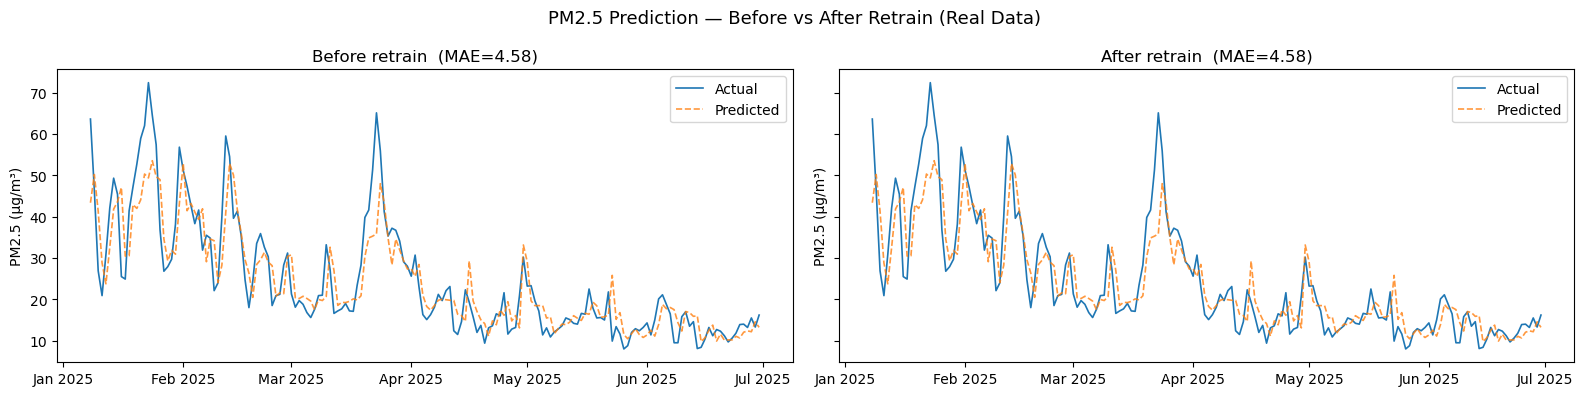

In [11]:
dag_run_id = result.get('dag_run_id')

if dag_run_id:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, preds, label in zip(
        axes,
        [y_pred, new_y_pred],
        ['Before retrain', 'After retrain']
    ):
        ax.plot(dates, y,     label='Actual',    linewidth=1.2)
        ax.plot(dates, preds, label='Predicted', linewidth=1.2, linestyle='--', alpha=0.8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        mae_val = evaluate_model(y, preds)['MAE']
        ax.set(title=f'{label}  (MAE={mae_val:.2f})', ylabel='PM2.5 (µg/m³)')
        ax.legend()

    plt.suptitle('PM2.5 Prediction — Before vs After Retrain (Real Data)', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Check Monitoring Log

In [12]:
log_path = '../results/monitoring_results.csv'

if os.path.exists(log_path):
    log_df = pd.read_csv(log_path)
    print(f'Total monitoring runs: {len(log_df)}')
    log_df.tail(5)
else:
    print('No monitoring log yet — run the monitoring DAG first.')

Total monitoring runs: 1
